# **Cardiovascular Disease Prediction Using Logistic Regression Model**

## **Introduction**

Cardiovascular disease (CVD) such as coronary heart disease (CHD), remains one of the leading causes of death worldwide. Early and accurate prediction of an individual’s risk for developing CHD over a 10-year period is crucial for timely intervention and prevention, which can help significantly reduce mortality.

**Goal of this project** is to develop a logistic regression model that helps predict the 10-year risk of CHD using relevant patient data.

**In order to succesfully reach the project's goal the following areas need to be adressed:**
1. Data preprocessing (handling missing values and identifying outliers).
2. Exploratory data analysis (understand variable distributions and potential risk factors).
3. Justified selection of variables to include in the model.
4. Spliting dataset into training and testing datasets.
5. Training a logistic regression model and evaluating its predictive performance.
6. Selecting appropriate classification metrics and determining the optimal decision threshold.

## **Data Preprocessing**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import RobustScaler 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report, 
    roc_auc_score, roc_curve, precision_recall_curve, f1_score, auc
)
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

data = pd.read_csv ("C:/Users/naujo/OneDrive/Stalinis kompiuteris/train.csv")
data = data.drop(data.columns[0], axis=1)
data.head()

,age,education,sex,is_smoking,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,64,2.0,F,YES,3.0,0.0,0,0,0,221.0,148.0,85.0,NaN,90.0,80.0,1
1,36,4.0,M,NO,0.0,0.0,0,1,0,212.0,168.0,98.0,29.77,72.0,75.0,0
2,46,1.0,F,YES,10.0,0.0,0,0,0,250.0,116.0,71.0,20.35,88.0,94.0,0
3,50,1.0,M,YES,20.0,0.0,0,1,0,233.0,158.0,88.0,28.26,68.0,94.0,1
4,64,1.0,F,YES,30.0,0.0,0,0,0,241.0,136.5,85.0,26.42,70.0,77.0,0


In [4]:
data.shape

(3390, 16)

By primarly looking at the data, we see that this dataset provides information about patient's age, education, sex, if they smoke or not and if they do how many cigarettes per day, if a patient was on blood pressure medication, if they previously had a stroke, if they were hypertensive, if the patient had diabetes, their total cholesterol level, systolic and diastolic blood pressure, their body mass index, heartrate, their glucose level and if they have 10-year risk of CHD (id column was excluded because it does not contain information that later on would be relevant when predicting).

Also this dataset consists of 3390 rows and 16 columns.

In [6]:
print(f"Data types:\n {data.dtypes}")

Data types:
 age                  int64
education          float64
sex                 object
is_smoking          object
cigsPerDay         float64
BPMeds             float64
prevalentStroke      int64
prevalentHyp         int64
diabetes             int64
totChol            float64
sysBP              float64
diaBP              float64
BMI                float64
heartRate          float64
glucose            float64
TenYearCHD           int64
dtype: object


In [7]:
smoking_zero_cigs = data[(data['is_smoking'] == 'Yes') & (data['cigsPerDay'] == 0)]
print(f"Number of cases when patient is smoking, but cigsPerDay value is 0: {smoking_zero_cigs.shape[0]}")

Number of cases when patient is smoking, but cigsPerDay value is 0: 0


By inspecting each column's data type, we observe that columns such as sex and is_smoking are of type object, which means their values need to be transformed into numerical format, as modeling algorithms require numeric input.

Additionally, it is important to note that the is_smoking and cigsPerDay columns contain overlapping information. Upon further inspection, it was confirmed that there are no cases where a patient is marked as a smoker (*is_smoking = 'Yes'*) while reporting 0 cigarettes per day. Based on this, the decision was made to retain only the cigsPerDay column, as it effectively captures both whether a patient smokes and how heavily they smoke.

Therefore only sex column needs to be transformed. For this case letter **<span style="color: blue;">M (refering to male)</span>** will be tranformed to **<span style="color: blue;">0</span>** and letter **<span style="color: red;">F (refering to female)</span>** will be transformed to **<span style="color: red;">1</span>**.

### Transforming data to numerical format

In [9]:
data = data.drop(columns=['is_smoking'])

data['sex'] = data['sex'].map({'M': 0, 'F': 1})
data.head()

,age,education,sex,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,64,2.0,1,3.0,0.0,0,0,0,221.0,148.0,85.0,NaN,90.0,80.0,1
1,36,4.0,0,0.0,0.0,0,1,0,212.0,168.0,98.0,29.77,72.0,75.0,0
2,46,1.0,1,10.0,0.0,0,0,0,250.0,116.0,71.0,20.35,88.0,94.0,0
3,50,1.0,0,20.0,0.0,0,1,0,233.0,158.0,88.0,28.26,68.0,94.0,1
4,64,1.0,1,30.0,0.0,0,0,0,241.0,136.5,85.0,26.42,70.0,77.0,0


### Checking for duplicate values

In [11]:
print(f"Number of duplicate rows: {data.duplicated().sum()}")
print(f"Number of duplicate columns: {data.T.duplicated().sum()}")

Number of duplicate rows: 0
Number of duplicate columns: 0


Ensuring there are no duplicate rows or columns in the dataset is essential for maintaining data integrity and model reliability.
Duplicate rows can distort statistical analysis and bias the model by giving certain observations more weight than they deserve. Similarly, duplicate columns can introduce multicollinearity, which may weaken the model's interpretability and accuracy.

### Checking for null values

In [14]:
null_count = data.isnull().sum()
null_percentage = (null_count / len(data)) * 100

null_data = pd.DataFrame({
    'Null Count': null_count,
    'Null Percentage': null_percentage.round(2)
})

print(null_data[null_data['Null Count'] > 0])

            Null Count  Null Percentage
education           87             2.57
cigsPerDay          22             0.65
BPMeds              44             1.30
totChol             38             1.12
BMI                 14             0.41
heartRate            1             0.03
glucose            304             8.97


An assessment of missing values in the dataset revealed that most variables had a low percentage of missing data, with the exception of the glucose variable, which had approximately **9%** missing values. 

Handling missing data is critical because it can introduce bias or reduce the model's predictive performance if not addressed properly, therefore addressing these missing values ensures a more complete dataset and improves the reliability of the logistic regression model.

To do so, appropriate imputation techniques, such as using the mean or median values or model-based imputation, need to be applied.

Since most columns with missing values have a relatively low percentage of nulls, the *median* will be used for imputation. This method is simple and effective when only a small portion of the data is missing.

However, the glucose column has a significantly higher proportion of missing values, which could impact model's performance if imputed too simply. Therefore, a more advanced method — *KNN imputation* — will be applied, which considers similarities between rows to make more context aware imputations.

**(null values will be imputed later in the project, after spliting the data into training and testing parts in order to avoid data leakage)**

### Checking for outliers

In [17]:
non_binary_cols = ['age', 'education', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']

total_rows = data.shape[0]

for col in non_binary_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
    num_outliers = outliers.shape[0]
    percent_outliers = (num_outliers / total_rows) * 100

    print(f"\nColumn: {col}")
    print(f"Number of outliers: {num_outliers} ({percent_outliers:.2f}%)")
    
    if not outliers.empty:
        sorted_outliers = outliers.sort_values(by=col, ascending=True)
        print(sorted_outliers[[col]])


Column: age
Number of outliers: 0 (0.00%)

Column: education
Number of outliers: 0 (0.00%)

Column: cigsPerDay
Number of outliers: 9 (0.27%)
      cigsPerDay
42          60.0
76          60.0
482         60.0
869         60.0
1774        60.0
2075        60.0
2222        60.0
3374        60.0
2985        70.0

Column: totChol
Number of outliers: 43 (1.27%)
      totChol
2231    107.0
1708    113.0
3387    352.0
3308    352.0
2296    352.0
1026    352.0
1741    353.0
2420    354.0
2631    355.0
491     356.0
2188    358.0
2557    358.0
998     360.0
659     361.0
924     362.0
2207    363.0
3183    364.0
1461    365.0
2519    366.0
1034    366.0
1318    366.0
1796    367.0
1371    370.0
1374    372.0
2434    373.0
2505    380.0
661     382.0
112     382.0
1938    390.0
978     390.0
912     391.0
194     391.0
1740    392.0
1997    398.0
3326    410.0
2445    410.0
2555    410.0
2534    432.0
220     439.0
2123    453.0
733     464.0
423     600.0
512     696.0

Column: sysBP
Number of

No identified outliers were removed from the dataset. Approximately the percentage of outliers in columns ranges from 0.27% to 4.66%, where in most cases it's way less than 5%. There is no significant indication that identified outliers are data entry errors, rather they may reflect valid extreme cases. Therefore, removing them could reduce the model’s ability to learn from rare but important patterns, potentially reducing its generalization performance, especially in edge-case predictions.

But also it is worth noticing, that if some of the outliers are actually irrelevant, this could have an impact on model's accuracy.

## **Exploratory Data Analysis**

To help have a better understanding of the dataset and possible challanges that might occur, EDA is performed. Let's begin by checking the target variable (TenYearCHD) distribution:

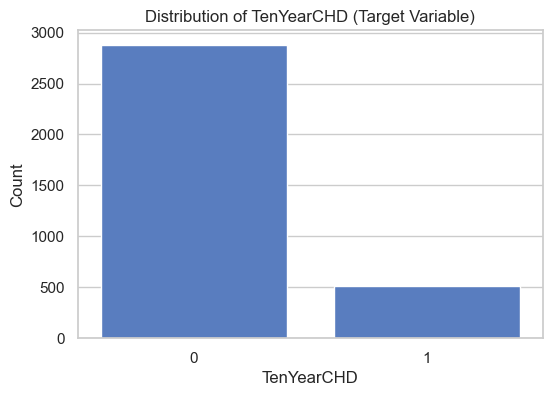

Class 0 (No CHD): 2879 instances, representing 84.93% of the dataset.
Class 1 (CHD): 511 instances, representing 15.07% of the dataset.


In [26]:
sns.set_theme(style="whitegrid", palette="muted")

plt.figure(figsize=(6, 4))
sns.countplot(x='TenYearCHD', data=data)
plt.title('Distribution of TenYearCHD (Target Variable)')
plt.xlabel('TenYearCHD')
plt.ylabel('Count')
plt.show()

chd_counts = data['TenYearCHD'].value_counts()
chd_percentages = data['TenYearCHD'].value_counts(normalize=True) * 100 

print(f"Class 0 (No CHD): {chd_counts.loc[0]} instances, representing {chd_percentages.loc[0]:.2f}% of the dataset.")
print(f"Class 1 (CHD): {chd_counts.loc[1]} instances, representing {chd_percentages.loc[1]:.2f}% of the dataset.")

By looking at the distribution of ten year CHD, we notice a significant **class imbalance**, with only about 15% of patients developing TenYearCHD (*the positive class*). This imbalance can cause the Logistic Regression model to become biased towards the majority class, potentially leading to a high number of dangerous *False Negatives* where actual CHD cases are missed. Knowing this, it indicates that we should consider appropriate metrics like Recall and F1 Scores, to help thorougly understand how well the model works, because accuracy alone will not be the best metric to describe model's performance.

Moreover, lets look at other non-binary columns and their distributions.

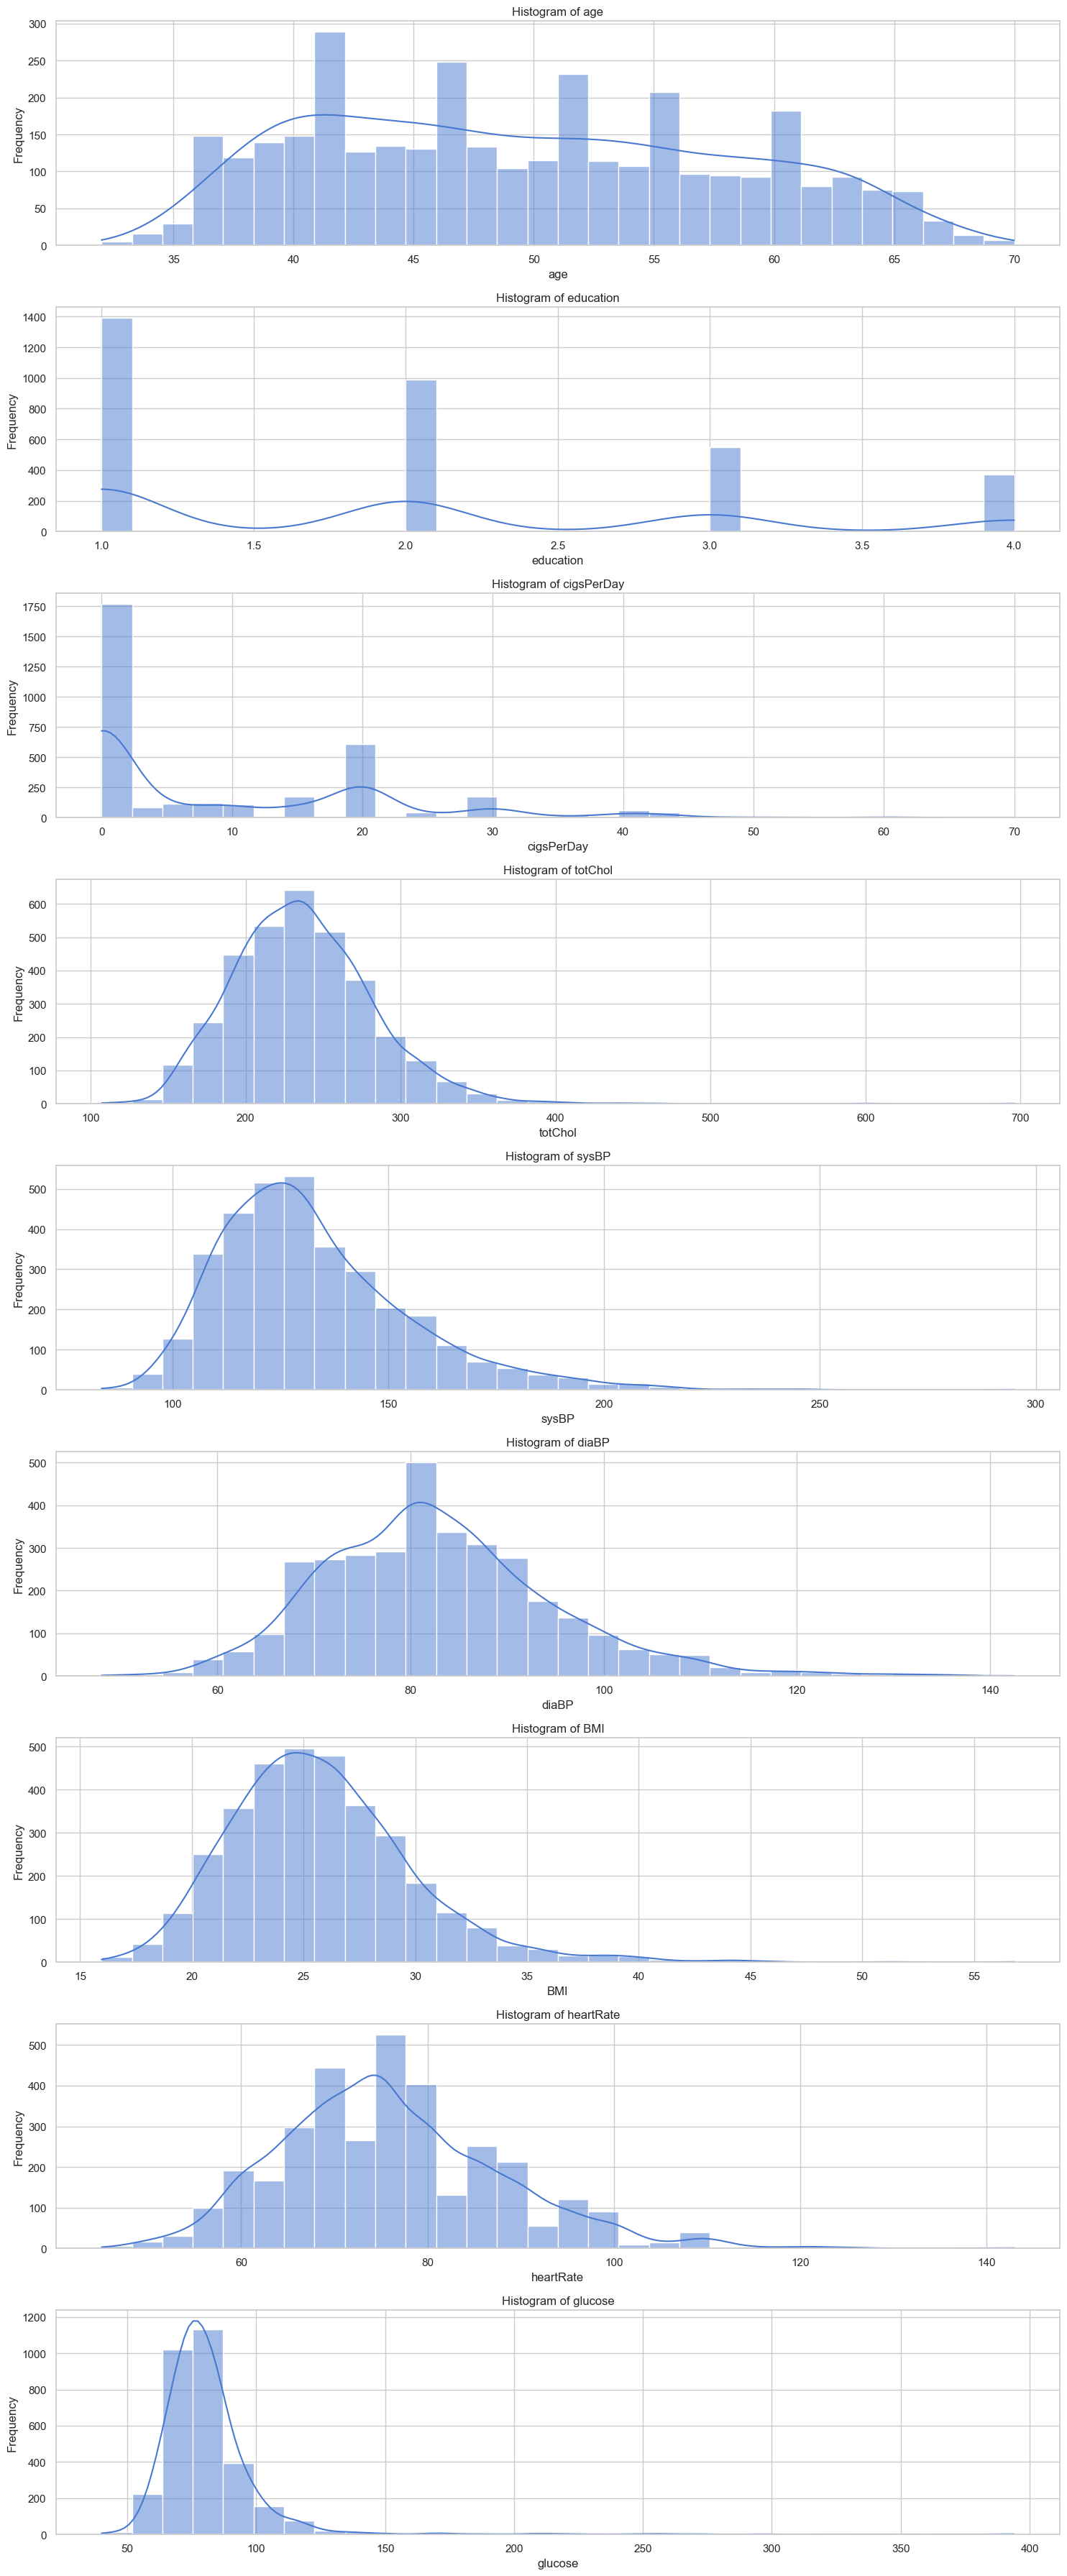

In [28]:
sns.set_theme(style="whitegrid", palette="muted")

plt.figure(figsize=(15, len(non_binary_cols)*4))

for i, col in enumerate(non_binary_cols, 1):
    plt.subplot(len(non_binary_cols), 1, i)
    sns.histplot(data[col], bins=30, kde=True)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

The results show that many of the inspected columns have right-skewed distributions. For such columns as totChol, sysBP, diaBP, BMI, heartRate, and glucose, a log transformation will be needed to perform in order to reduce their skewness, normalize their distributions, and mitigate the disproportionate influence of outliers.

Moving forward with EDA, lets inspect other columns.

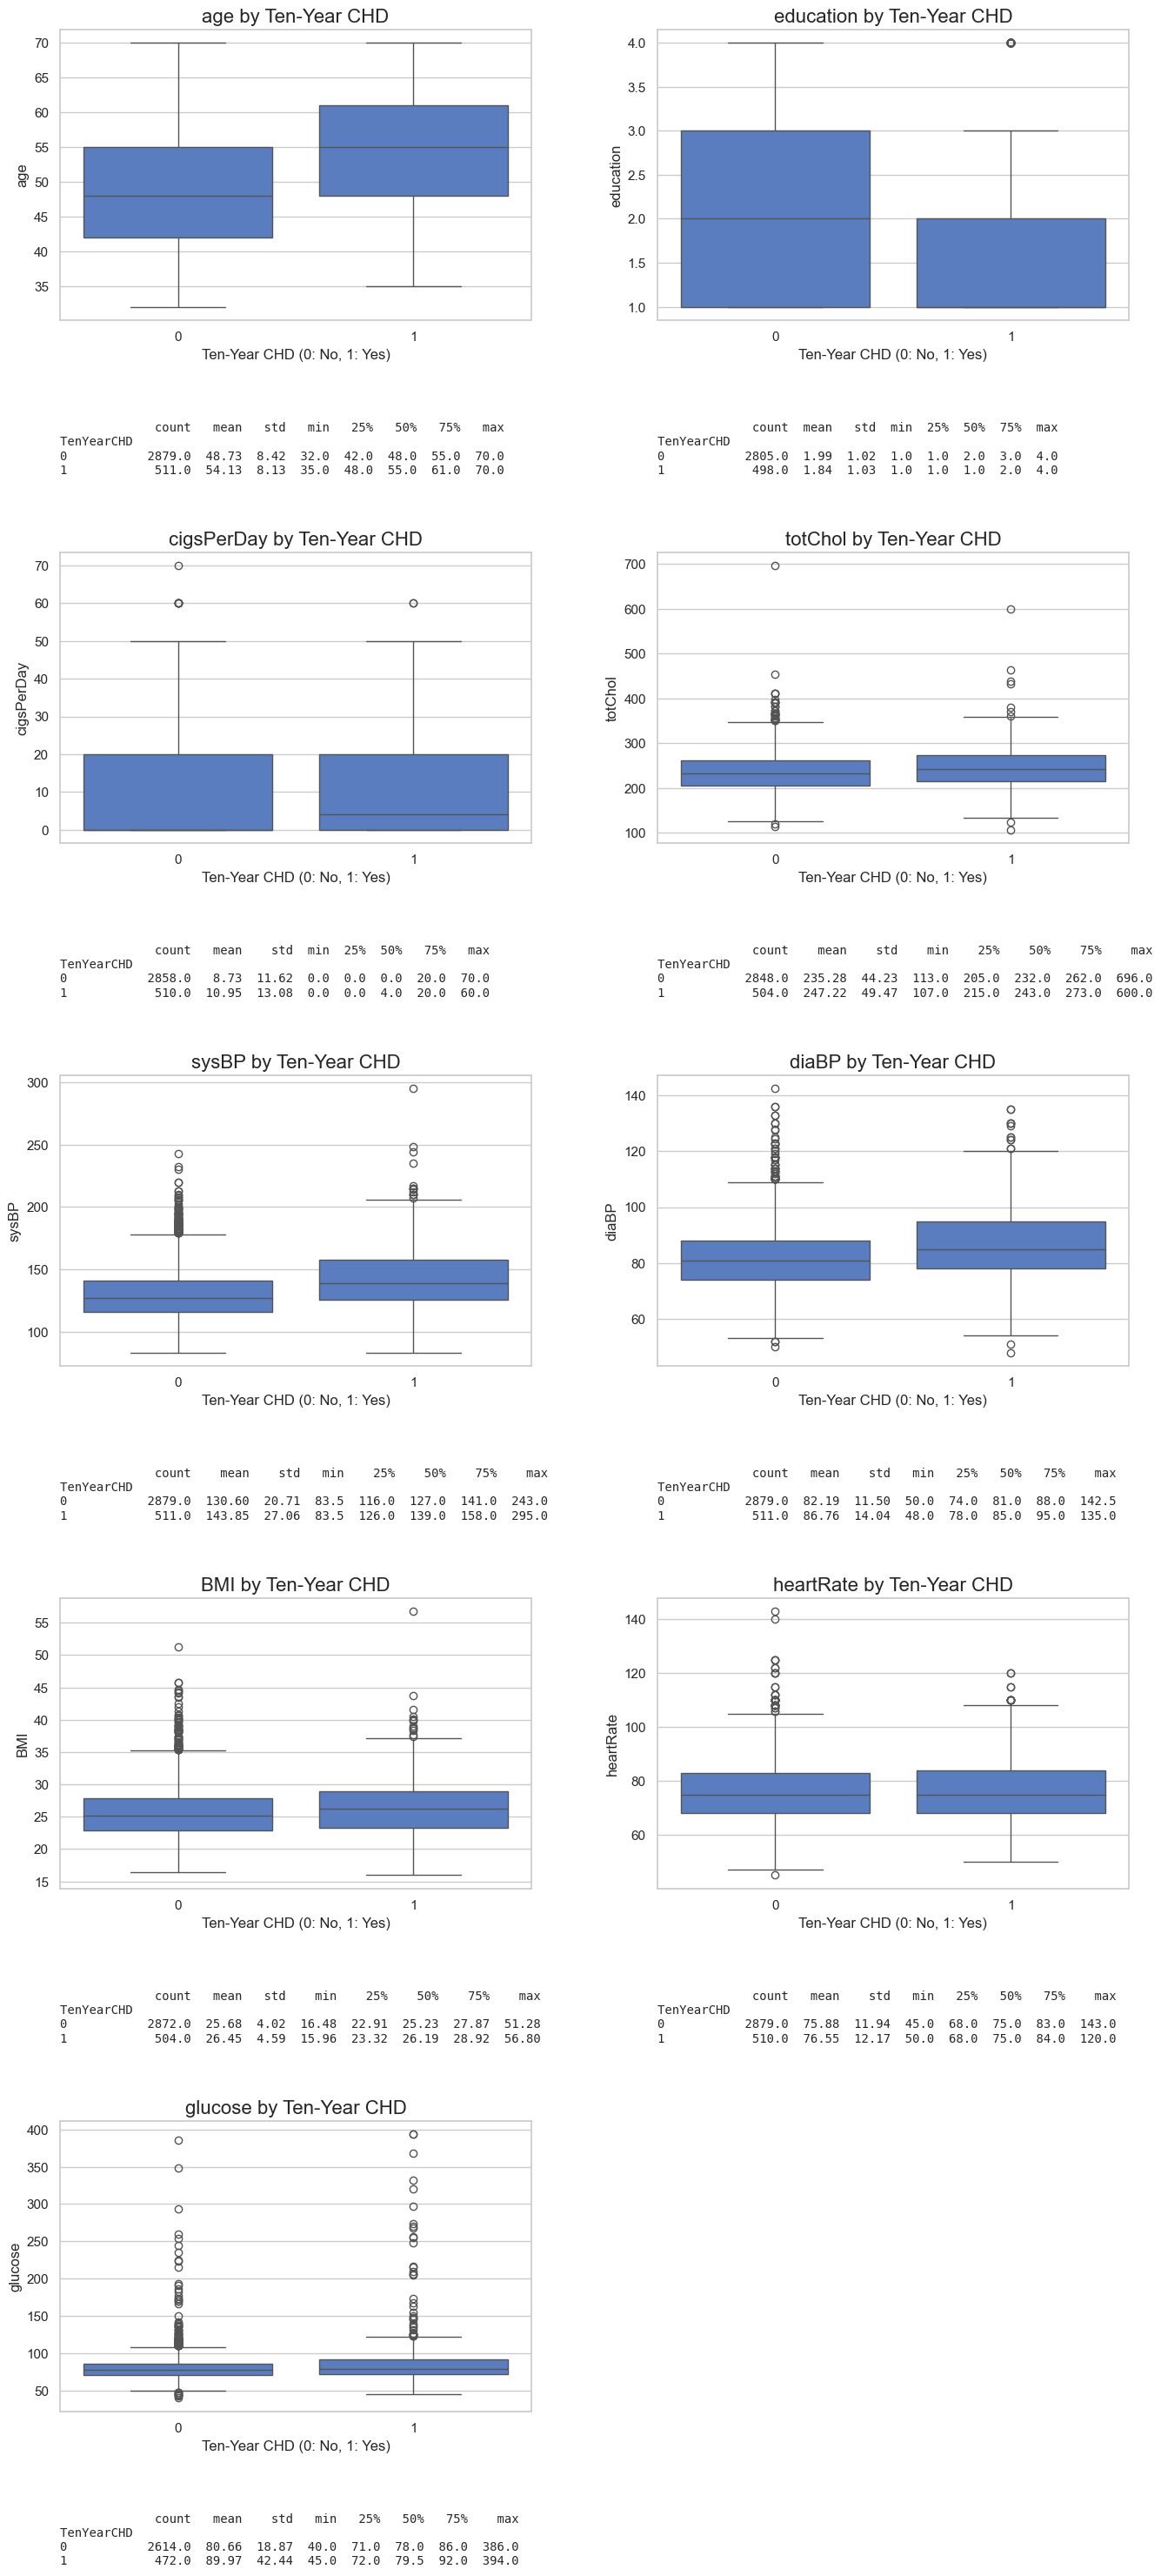

In [33]:
variables = ['age', 'education', 'cigsPerDay', 'totChol', 'sysBP',
             'diaBP', 'BMI', 'heartRate', 'glucose']

sns.set(style='whitegrid', palette="muted")

n_cols = 2 
n_rows = (len(variables) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 6)) 
axes = axes.flatten()

for idx, var in enumerate(variables):
    ax = axes[idx]
    
    sns.boxplot(x='TenYearCHD', y=var, data=data, ax=ax)
    ax.set_title(f'{var} by Ten-Year CHD', fontsize=16)
    ax.set_xlabel('Ten-Year CHD (0: No, 1: Yes)')
    ax.set_ylabel(var)
    
    stats = data.groupby('TenYearCHD')[var].describe()
    stats = stats[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']]
    stats_rounded = stats.round(2)
    text = stats_rounded.to_string()
    
    ax.text(0, -0.35, text, fontsize=10, ha='left', va='top', family='monospace', transform=ax.transAxes)

for i in range(len(variables), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.subplots_adjust(hspace=0.8) 
plt.show()

The analysis reveals the following important patterns:

* Age: older individuals are more likely to develop CHD, with the median age of those affected being higher (55 years) than those unaffected (48 years). This confirms age as a strong predictor of CHD risk.
* Education: patients who developed CHD tend to have lower education levels. This suggests that lower educational may be linked to increased CHD risk, potentially reflecting differences in health knowledge and lifestyle behaviors.
* Cigarette Consumption (cigsPerDay): there is a difference in smoking habits, with the CHD group smoking more cigarettes daily (median of 4) compared to the non-CHD group (median of 0. Smoking frequency can be a relevant risk factor.
* Total Cholesterol (totChol): individuals with CHD generally have slightly higher cholesterol levels, although both groups show wide variability and outliers. In general, this indicates cholesterol can be useful risk indicator.
* Systolic Blood Pressure (sysBP): a positive association exists between higher systolic blood pressure and CHD, with CHD cases exhibiting elevated medians and extreme outliers, suggesting sysBP can be a critical predictor.
* Diastolic Blood Pressure (diaBP): similar to systolic pressure, higher diastolic blood pressure is observed among CHD patients, reinforcing its role as a cardiovascular risk factor.
* Body Mass Index (BMI): higher median BMI values in the CHD group indicate that obesity contributes to increased CHD risk. Both groups include obese individuals, but higher BMI is more prone with CHD patients.
* Heart Rate: the distributions of heart rate are similar between groups, with the non-CHD group even showing more high-end outliers. This suggests heart rate can be a less effective individual predictor in this dataset.
* Glucose: elevated glucose levels are associated with CHD presence, with the CHD group showing both higher medians and more extreme outliers, emphasizing glucose’s predictive value for cardiovascular risk.

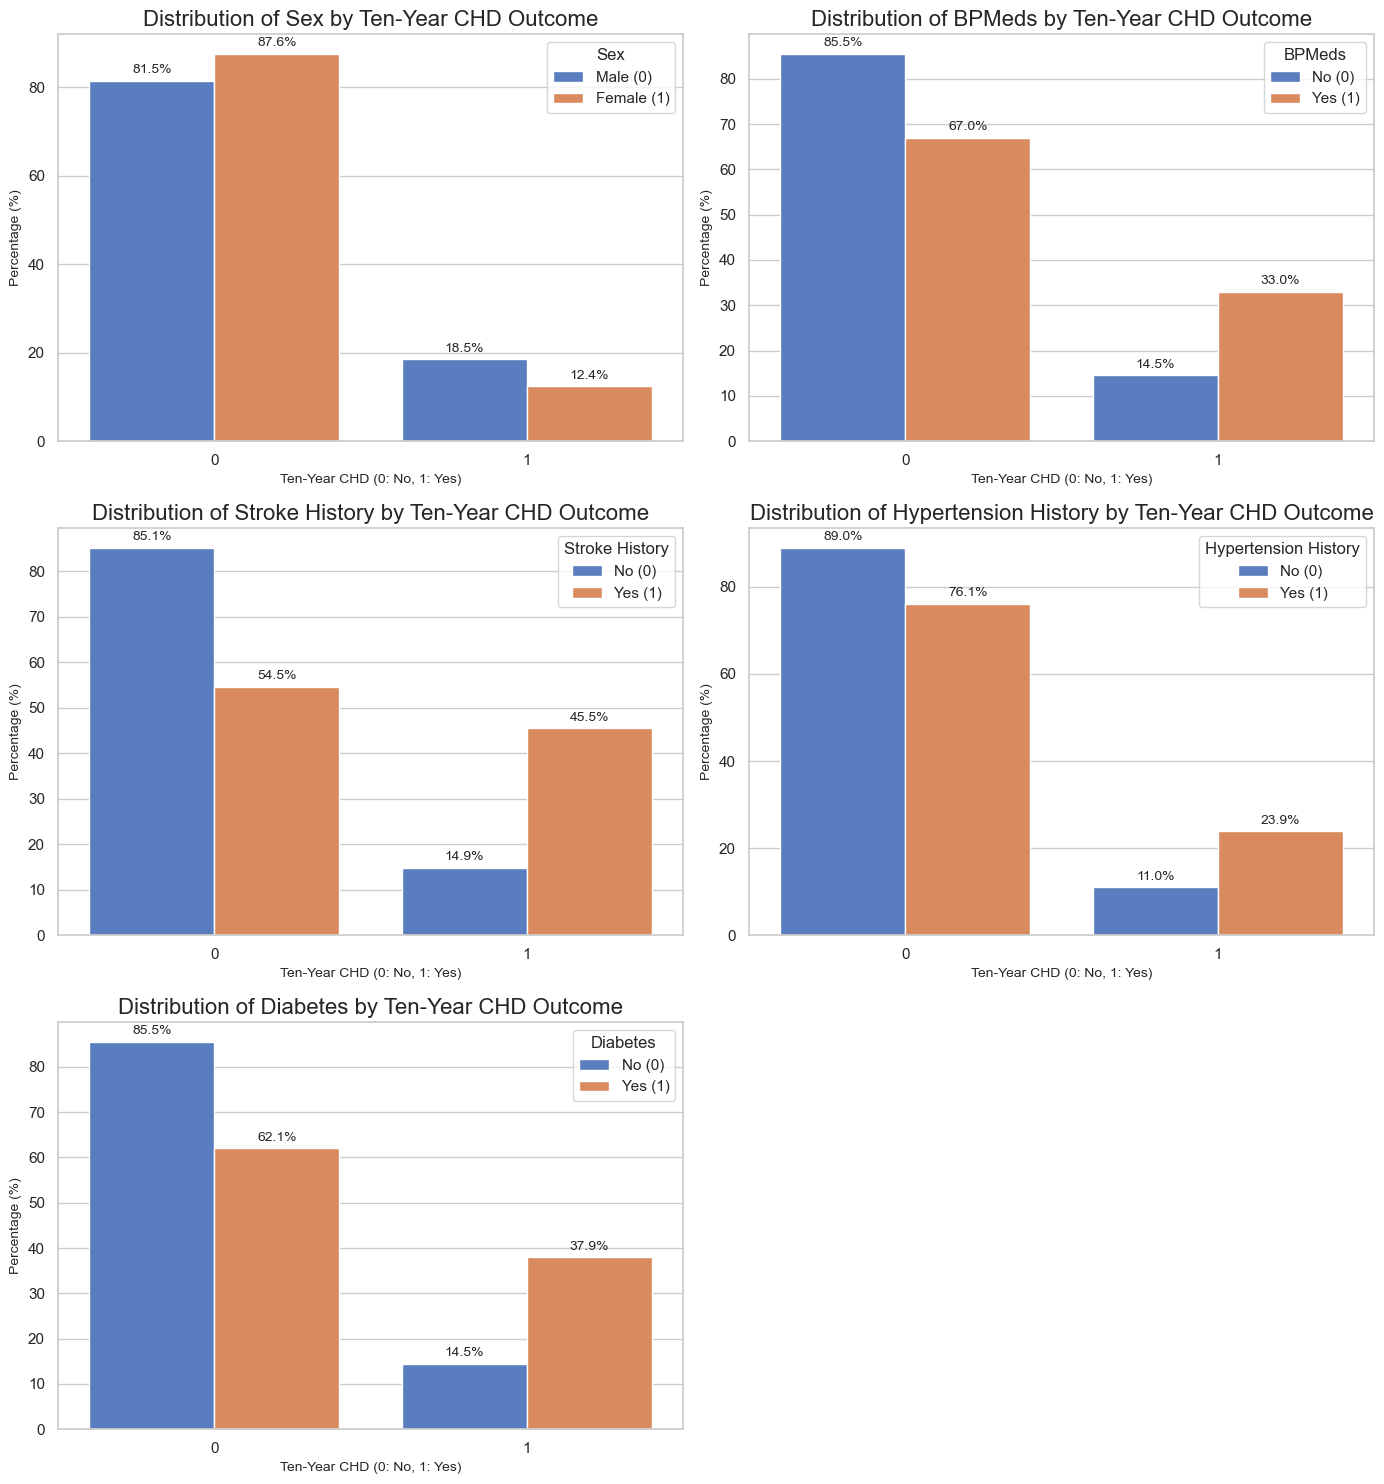

In [35]:
sns.set(style='whitegrid', palette="muted")

categorical_vars = ['sex', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes']
var_labels = {
    'sex': ('Sex', ['Male (0)', 'Female (1)']),
    'BPMeds': ('BPMeds', ['No (0)', 'Yes (1)']),
    'prevalentStroke': ('Stroke History', ['No (0)', 'Yes (1)']),
    'prevalentHyp': ('Hypertension History', ['No (0)', 'Yes (1)']),
    'diabetes': ('Diabetes', ['No (0)', 'Yes (1)'])
}

n_cols = 2
n_rows = (len(categorical_vars) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 5))
axes = axes.flatten()

for idx, var in enumerate(categorical_vars):
    ax = axes[idx]

    ctab = pd.crosstab(data['TenYearCHD'], data[var], normalize='columns') * 100
    ctab = ctab.T.reset_index().melt(id_vars=var, value_name='Percentage', var_name='TenYearCHD')

    sns.barplot(data=ctab, x='TenYearCHD', y='Percentage', hue=var, ax=ax)

    title, legend_labels = var_labels[var]
    ax.set_title(f'Distribution of {title} by Ten-Year CHD Outcome', fontsize=16)
    ax.set_xlabel('Ten-Year CHD (0: No, 1: Yes)', fontsize=10)
    ax.set_ylabel('Percentage (%)', fontsize=10)

    handles, _ = ax.get_legend_handles_labels()
    ax.legend(handles=handles, title=title, labels=legend_labels, loc='upper right')

    for p in ax.patches:
        height = p.get_height()
        if height > 0: 
            ax.text(
                p.get_x() + p.get_width() / 2,
                height + 1,  
                f'{height:.1f}%', 
                ha='center', 
                va='bottom', 
                fontsize=10
            )

for i in range(len(categorical_vars), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

Moreover, analysis of binary features reveal the following insights:

* Sex: males in the dataset demonstrate a higher incidence of coronary heart disease, with approximately 18% of males developing CHD compared to 12% of females. This suggests that sex is a possible predictor in the ten year CHD.
* Blood Pressure Medication (BPMeds): individuals taking blood pressure medication exhibit a higher risk of developing CHD (33%) compared to those not on medication (only ~14%). This difference indicates BPMeds can be an important predictor.
* Stroke (prevalentStroke): patients with a history of stroke show a remarkably higher CHD incidence ( about 45%) compared to those without (nearly 15%). This suggests, that prevalentStroke can be an important predictive feature.
* Pevalent Hypertension (prevalentHyp): individuals with prevalent hypertension seems to be more likely to develop CHD (nearly 24%) compared to those without (11%). This difference confirms prevalentHyp as a possible predictor.
* Diabetes: individuals with diabetes are more prone to developing CHD (nearly 38%) compared to non-diabetics (about 14%). This confirms diabetes can be a possible predictor for cardiovascular disease.

**Correlation**

By checking correlation, this can inform and help make decisions on which variables are likely to be powerful predictors and should be included in the Logistic Regression model. Additionally, it can suggest about multicollinearity among independent features.

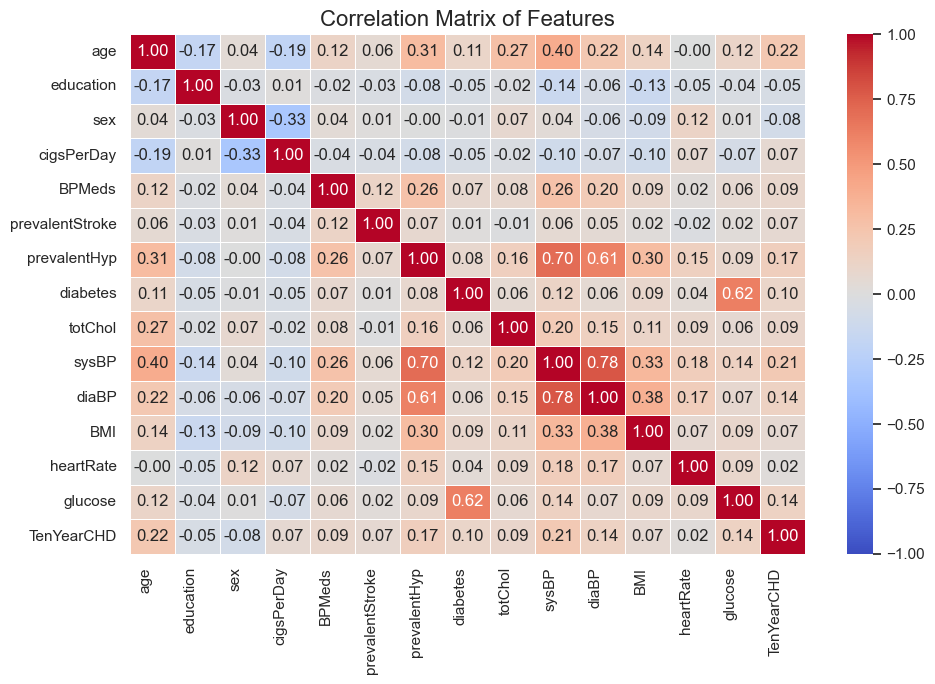

In [39]:
columns_to_check = [
    'age', 'education', 'sex', 'cigsPerDay', 'BPMeds', 'prevalentStroke',
    'prevalentHyp', 'diabetes', 'totChol', 'sysBP', 'diaBP', 'BMI',
    'heartRate', 'glucose', 'TenYearCHD'
]

correlation_matrix = data[columns_to_check].corr()

plt.figure(figsize=(10, 7))  
sns.heatmap(
    correlation_matrix,
    annot=True,        
    cmap='coolwarm',   
    fmt=".2f",         
    linewidths=.5,     
    vmin=-1,           
    vmax=1            
)
plt.title('Correlation Matrix of Features', fontsize=16)
plt.xticks(rotation=90, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

The correlation matrix provides valuable insights into the relationships between features and their association with the TenYearCHD outcome. Notably, significant correlation is observed between sysBP and diaBP (0.78), and prevalentHyp with sysBP (0.7) and diaBP (0.61), suggesting these blood pressure related variables provide somewhat redundant information for the model, simmilarly glucose and diabetes correlate (0.62) as well.

To conclude, based on the EDA and correlation analysis that was performed we can make a decision to include such features in to the model: **age, sex, cigsPerDay, BPmeds, prevalentStroke, totChol, sysBP, BMI, heartRate, glucose**. Regarding sysBP, diaBP and prevalentHYP, since they all are strongly correlated with each other it was decided to keep only sysBP, since it has highest correlation with the dependant column. Also in the glucose and diabetes case, we can also notice a higher correlation between them, therefore glucose feature was chosen, since it has higher correlation with the TenYearCHD. For education column case, it was chosen to not include this feature in modelling regardless of EDA showing that higher education might be associated to people having more knowledge about healthcare, but correlation analysis shows that education has very low correlation with TenYearCHD and since this metric is not directly associated with health, education will not be included.

## **Modelling**

Firstly, lets choose the variables to include in the model. As discussed before, the variables that will be included are: age, sex, cigsPerDay, BPmeds, prevalentStroke, totChol, sysBP, BMI, heartRate, glucose.

In [44]:
final_columns_for_model = [
    "age",
    "sex",
    "cigsPerDay",
    "BPMeds",
    "prevalentStroke",
    "totChol",
    "sysBP",
    "BMI",
    "heartRate",
    "glucose",
    "TenYearCHD",
]

data_for_modelling = data[final_columns_for_model]
data_for_modelling.head()

,age,sex,cigsPerDay,BPMeds,prevalentStroke,totChol,sysBP,BMI,heartRate,glucose,TenYearCHD
0,64,1,3.0,0.0,0,221.0,148.0,NaN,90.0,80.0,1
1,36,0,0.0,0.0,0,212.0,168.0,29.77,72.0,75.0,0
2,46,1,10.0,0.0,0,250.0,116.0,20.35,88.0,94.0,0
3,50,0,20.0,0.0,0,233.0,158.0,28.26,68.0,94.0,1
4,64,1,30.0,0.0,0,241.0,136.5,26.42,70.0,77.0,0


Now, lets split the data in to two parts - for training and for testing. In this case 80/20 rule is used, where 80% of data is used for training and 20% of data is used for testing.

In [46]:
feature_matrix = data_for_modelling.drop('TenYearCHD', axis=1)
target_variable = data_for_modelling['TenYearCHD']

feature_matrix_train, feature_matrix_test, target_variable_train, target_variable_test = train_test_split(
    feature_matrix, target_variable, test_size=0.2, random_state=0, stratify=target_variable
)

print("Training set shape:", feature_matrix_train.shape)
print("Testing set shape:", feature_matrix_test.shape)

Training set shape: (2712, 10)
Testing set shape: (678, 10)


As we now have split the dataset into training and testing sets, we can impute missing values.

In [48]:
median_cols = feature_matrix_train.columns.drop('glucose')
knn_cols = ['glucose']

median_imputer = SimpleImputer(strategy='median')

feature_matrix_train_median = median_imputer.fit_transform(feature_matrix_train[median_cols])
feature_matrix_test_median = median_imputer.transform(feature_matrix_test[median_cols])

feature_matrix_train_median = pd.DataFrame(feature_matrix_train_median, columns=median_cols, index=feature_matrix_train.index)
feature_matrix_test_median = pd.DataFrame(feature_matrix_test_median, columns=median_cols, index=feature_matrix_test.index)

knn_imputer = KNNImputer(n_neighbors=5)

feature_matrix_train_glucose = knn_imputer.fit_transform(feature_matrix_train[knn_cols])
feature_matrix_test_glucose = knn_imputer.transform(feature_matrix_test[knn_cols])

feature_matrix_train_glucose = pd.DataFrame(feature_matrix_train_glucose, columns=knn_cols, index=feature_matrix_train.index)
feature_matrix_test_glucose = pd.DataFrame(feature_matrix_test_glucose, columns=knn_cols, index=feature_matrix_test.index)

feature_matrix_train_imputed = pd.concat([feature_matrix_train_median, feature_matrix_train_glucose], axis=1)
feature_matrix_test_imputed = pd.concat([feature_matrix_test_median, feature_matrix_test_glucose], axis=1)

feature_matrix_train_imputed = feature_matrix_train_imputed[feature_matrix_train.columns]
feature_matrix_test_imputed = feature_matrix_test_imputed[feature_matrix_test.columns]

In [49]:
print(feature_matrix_train_imputed.isnull().sum()) 

age                0
sex                0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
totChol            0
sysBP              0
BMI                0
heartRate          0
glucose            0
dtype: int64


In [50]:
print(feature_matrix_test_imputed.isnull().sum())  

age                0
sex                0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
totChol            0
sysBP              0
BMI                0
heartRate          0
glucose            0
dtype: int64


The results show that the null values were imputed successfully, now we can check for multicollinearity.

In [53]:
features_for_vif = [
    'age', 'sex', 'cigsPerDay', 'BPMeds', 'prevalentStroke', 'totChol', 'sysBP', 'BMI',
    'heartRate', 'glucose'
]

X = feature_matrix_train_imputed[features_for_vif].copy()

X_const = add_constant(X)

vif_df = pd.DataFrame()
vif_df["Feature"] = X_const.columns
vif_df["VIF"] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]

print(vif_df)

            Feature         VIF
0             const  122.359709
1               age    1.293614
2               sex    1.183369
3        cigsPerDay    1.197900
4            BPMeds    1.089529
5   prevalentStroke    1.012881
6           totChol    1.120263
7             sysBP    1.444994
8               BMI    1.164549
9         heartRate    1.077101
10          glucose    1.035780


No multicollinearity is detected between variables, since there are no VIF values higher than 5.

Another important aspect, that needs to be covered is dealing with skewness, that we identified at the beginning of the EDA part. Since this can influence the model's performance we will log columns used in the model which are skewed.

In [55]:
log_cols = ['totChol', 'sysBP', 'BMI', 'heartRate', 'glucose']

feature_matrix_train_imputed[log_cols] = feature_matrix_train_imputed[log_cols].apply(np.log)
feature_matrix_test_imputed[log_cols] = feature_matrix_test_imputed[log_cols].apply(np.log)

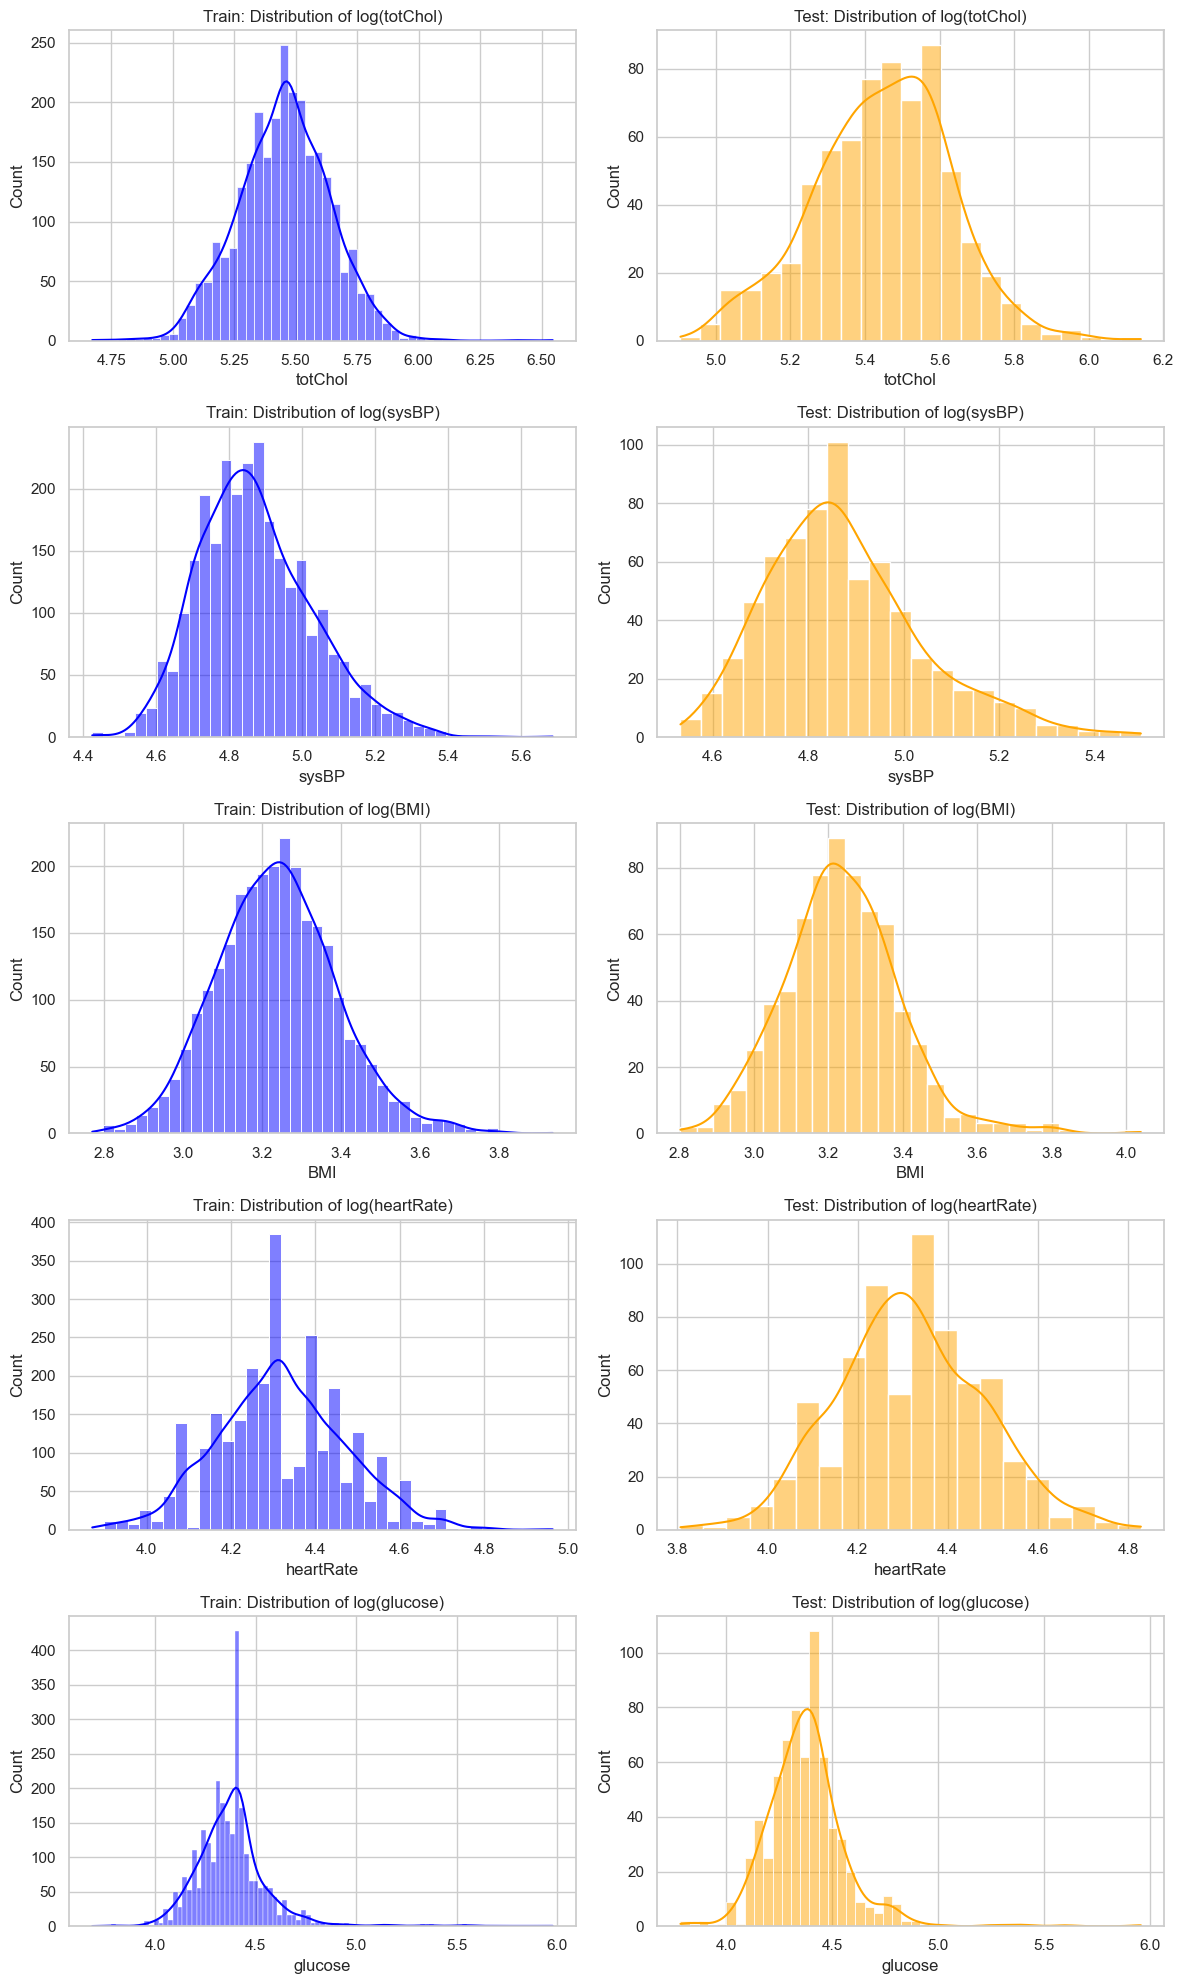

In [56]:
log_cols = ['totChol', 'sysBP', 'BMI', 'heartRate', 'glucose']

sns.set(style='whitegrid', palette='muted')

fig, axes = plt.subplots(len(log_cols), 2, figsize=(12, len(log_cols)*4))

for i, col in enumerate(log_cols):
    sns.histplot(feature_matrix_train_imputed[col], kde=True, ax=axes[i, 0], color='blue')
    axes[i, 0].set_title(f'Train: Distribution of log({col})')
    
    sns.histplot(feature_matrix_test_imputed[col], kde=True, ax=axes[i, 1], color='orange')
    axes[i, 1].set_title(f'Test: Distribution of log({col})')

plt.tight_layout()
plt.show()

By looking at the distribution charts we can see that skeweness was reduced after log transforming. 

Moreover, scaling is needed. Scaling is important in this case because it ensures that all numerical features contribute equally to the model, especially when they are on different scales. Without scaling, features with larger ranges can disproportionately influence the model, potentially leading to biased results.

In [58]:
cols_to_scale = ['age', 'cigsPerDay', 'totChol', 'sysBP', 'BMI', 'heartRate', 'glucose']

scaler = RobustScaler()

feature_matrix_train_imputed_scaled = feature_matrix_train_imputed.copy()
feature_matrix_train_imputed_scaled[cols_to_scale] = scaler.fit_transform(feature_matrix_train_imputed[cols_to_scale])

feature_matrix_test_imputed_scaled = feature_matrix_test_imputed.copy()
feature_matrix_test_imputed_scaled[cols_to_scale] = scaler.transform(feature_matrix_test_imputed[cols_to_scale])

In [59]:
print(feature_matrix_train_imputed_scaled[cols_to_scale].agg(['mean', 'std']).round(3).T)

             mean    std
age         0.041  0.614
cigsPerDay  0.447  0.590
totChol    -0.013  0.769
sysBP       0.105  0.758
BMI         0.017  0.776
heartRate   0.009  0.766
glucose     0.023  1.198


Results show that scaling worked. Each column now has a mean very close to 0 and a standard deviation about 1, which means the features are standardized and ready for modeling.

Finally, lets train the Logistic Regression Model.

In [63]:
model = LogisticRegression(max_iter=1000, random_state=0, class_weight='balanced')

model.fit(feature_matrix_train_imputed_scaled, target_variable_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=0)

Now, we lets evaluate model's performance.

--- Model Evaluation ---

Accuracy: 0.6770


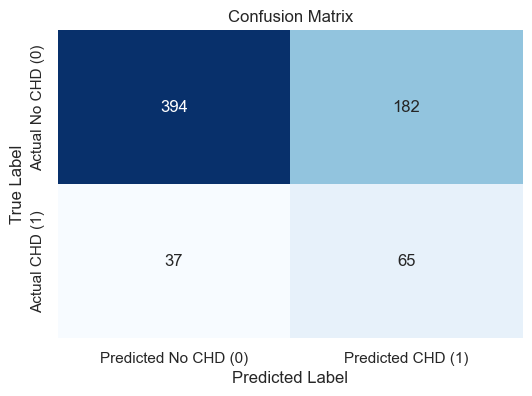


Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.68      0.78       576
           1       0.26      0.64      0.37       102

    accuracy                           0.68       678
   macro avg       0.59      0.66      0.58       678
weighted avg       0.82      0.68      0.72       678


ROC AUC Score: 0.7264


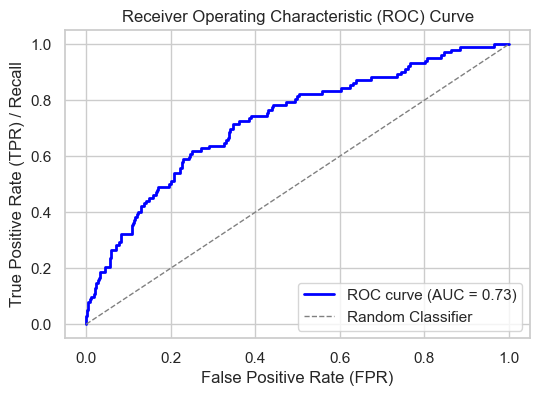

In [65]:
target_variable_pred = model.predict(feature_matrix_test_imputed_scaled)

target_variable_proba = model.predict_proba(feature_matrix_test_imputed_scaled)[:, 1]

print("--- Model Evaluation ---")

accuracy = accuracy_score(target_variable_test, target_variable_pred)
print(f"\nAccuracy: {accuracy:.4f}")

conf_matrix = confusion_matrix(target_variable_test, target_variable_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted No CHD (0)', 'Predicted CHD (1)'],
            yticklabels=['Actual No CHD (0)', 'Actual CHD (1)'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

class_report = classification_report(target_variable_test, target_variable_pred)
print("\nClassification Report:")
print(class_report)

roc_auc = roc_auc_score(target_variable_test, target_variable_proba)
print(f"\nROC AUC Score: {roc_auc:.4f}")

fpr, tpr, thresholds = roc_curve(target_variable_test, target_variable_proba)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR) / Recall')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

The logistic regression model achieved an overall accuracy of **85.69%**. However, a closer look at the confusion matrix and classification report reveal some key concerns:

* The model correctly predicted **572** out of **678** total cases as negative (*no CHD*), but only **9** out of **102** positive cases (*CHD*) were correctly identified.
* The recall for the positive class (*CHD*) is very low at **0.09**, indicating the model missed most true CHD cases (*high false negative rate*), which is critical in clinical settings.
* The precision for the positive class is **0.69**, meaning that when the model predicts CHD, it’s usually correct, but it does so rarely.
* The F1-score for the positive class is only **0.16**, reflecting a poor balance between precision and recall.
* The ROC AUC score is 0.726, suggesting the model has moderate ability to distinguish between CHD and non-CHD cases.

While the model performs quite well in identifying individuals without CHD, it struggles to detect those at risk. This imbalance highlights the need for optimizing the decision threshold to better capture the positive class which is the most important in our case.


Optimal Threshold (maximizing F1-score): 0.5542


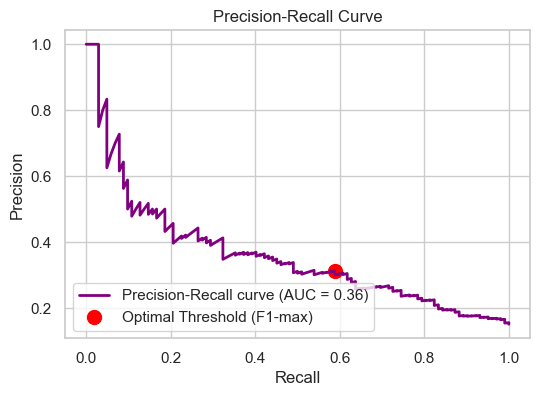

In [67]:
precisions, recalls, thresholds = precision_recall_curve(target_variable_test, target_variable_proba)

f1_scores = (2 * precisions * recalls) / (precisions + recalls)
f1_scores = np.nan_to_num(f1_scores)

optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]
optimal_f1_score = f1_scores[optimal_idx]

print(f"\nOptimal Threshold (maximizing F1-score): {optimal_threshold:.4f}")

plt.figure(figsize=(6, 4))
plt.plot(recalls, precisions, color='purple', lw=2, label=f'Precision-Recall curve (AUC = {auc(recalls, precisions):.2f})')
plt.scatter(recalls[optimal_idx], precisions[optimal_idx], marker='o', color='red', s=100, label=f'Optimal Threshold (F1-max)')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

When looking for the most optimal threshold, results show, that lowering the threshold to 0.1755:

* Increased recall - the model catches more true CHD cases.
* Reduced precision - now the model makes more false positive predictions.

Overall, the found threshold (0.1755) where F1-score is maximized seems to balance the trade-off effectively.

--- Model Evaluation at Optimal Threshold (0.5542) ---

Accuracy: 0.7434


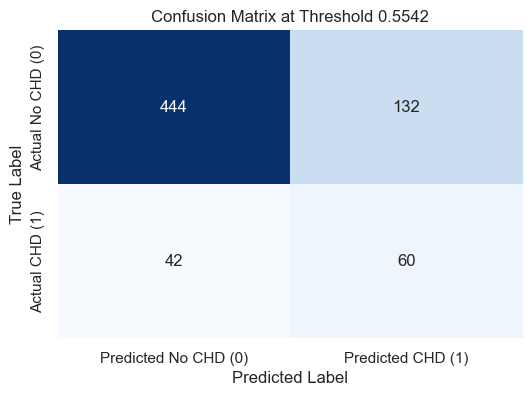


Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.77      0.84       576
           1       0.31      0.59      0.41       102

    accuracy                           0.74       678
   macro avg       0.61      0.68      0.62       678
weighted avg       0.82      0.74      0.77       678


ROC AUC Score: 0.7264


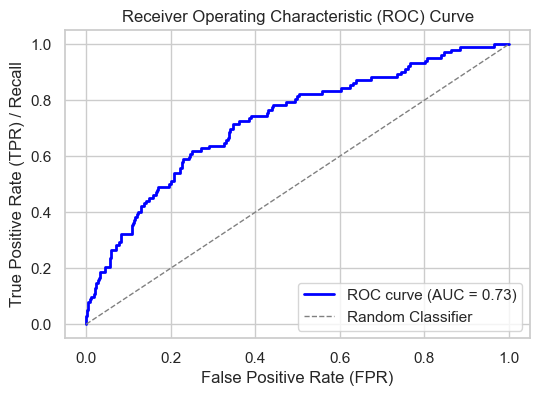

In [69]:
target_variable_proba = model.predict_proba(feature_matrix_test_imputed_scaled)[:, 1]

target_variable_pred_optimal = (target_variable_proba >= 0.5542).astype(int)

print(f"--- Model Evaluation at Optimal Threshold ({optimal_threshold:.4f}) ---")

accuracy_optimal = accuracy_score(target_variable_test, target_variable_pred_optimal)
print(f"\nAccuracy: {accuracy_optimal:.4f}")

conf_matrix_optimal = confusion_matrix(target_variable_test, target_variable_pred_optimal)
plt.figure(figsize=(6, 4))
sns.heatmap(
    conf_matrix_optimal,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Predicted No CHD (0)", "Predicted CHD (1)"],
    yticklabels=["Actual No CHD (0)", "Actual CHD (1)"],
)
plt.title(f"Confusion Matrix at Threshold {optimal_threshold:.4f}")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

class_report_optimal = classification_report(
    target_variable_test, target_variable_pred_optimal
)
print("\nClassification Report:")
print(class_report_optimal)

roc_auc = roc_auc_score(target_variable_test, target_variable_proba)
print(f"\nROC AUC Score: {roc_auc:.4f}")

fpr, tpr, thresholds_roc_curve = roc_curve(target_variable_test, target_variable_proba)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color="blue", lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--", label="Random Classifier")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR) / Recall")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

After applying the optimal decision threshold (0.1755), the model showed a significant increase in recall for the CHD class (**from 0.09 to 0.61**), which is critical in a clinical context where false negatives must be minimized. Although precision dropped (**to 0.31**), the F1-score improved from **0.16 to 0.41**, reflecting a better balance between precision and recall. The ROC AUC score remained at 0.726, indicating fair discriminatory power. This adjustment trades off some overall accuracy for greater sensitivity in detecting CHD, aligning with the goal of early identification in high-risk individuals.

## **Conclusion and Reccomendations**
The developed Logistic Regression Model with an optimal decision threshold of **0.1752** demonstrates performance for predicting 10-year coronary heart disease (CHD) risk, where it correctly predicted about **74%** of cases. The model successfully identified **61%** of individuals who actually developed CHD. This is especially important in clinical settings, where missing true positive cases could lead to delayed diagnosis and treatment. There is room for improvement and model's performance could be improved (61% of correctly identifying true CHD cases is still pretty low). 

**The following reccomendations suggest possible ways how the model could be improved:**

1. Try incorporating more features in to the model (that were not included), this could have an impact on the model's better performance.
2. Try other classification algorithms (Decision Trees)
3. Better asses outliers (discuss with medical professionals, look at outlier cases and treat them more carefully)